# 4. Finale Visualisierungen - Titanic Projekt



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [8]:
data_path = Path('../data/processed/titanic_cleaned.csv')
df = pd.read_csv(data_path)

target_col = 'Survived' if 'Survived' in df.columns else 'survived'
sex_col = 'Sex' if 'Sex' in df.columns else 'sex'
pclass_col = 'Pclass' if 'Pclass' in df.columns else 'pclass'
age_col = 'Age' if 'Age' in df.columns else 'age'
fare_col = 'Fare' if 'Fare' in df.columns else 'fare'

print(f'Daten geladen: {data_path}')
print(f'Form: {df.shape[0]} Zeilen, {df.shape[1]} Spalten')

Daten geladen: ..\data\processed\titanic_cleaned.csv
Form: 891 Zeilen, 12 Spalten


## Visualisierung 1: Ueberlebensrate nach Geschlecht (H1)

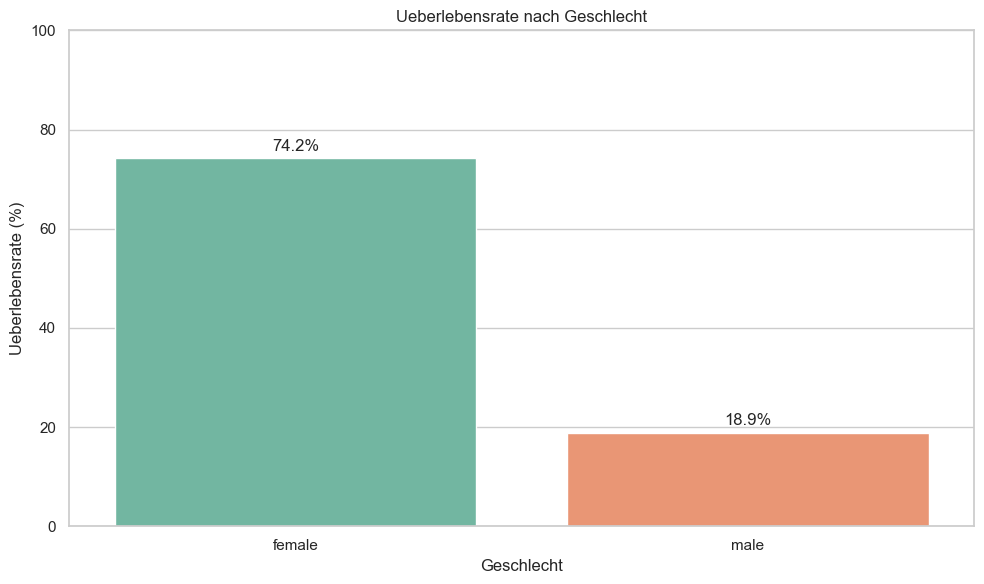

In [13]:
survival_by_sex = (df.groupby(sex_col)[target_col].mean() * 100).sort_values(ascending=False)

plot_df = pd.DataFrame({
    'Geschlecht': survival_by_sex.index,
    'Rate': survival_by_sex.values
})

ax = sns.barplot(data=plot_df, x='Geschlecht', y='Rate', hue='Geschlecht', palette='Set2', legend=False)
ax.set_title('Ueberlebensrate nach Geschlecht')
ax.set_xlabel('Geschlecht')
ax.set_ylabel('Ueberlebensrate (%)')
ax.set_ylim(0, 100)

for i, v in enumerate(plot_df['Rate']):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## Visualisierung 2: Ueberlebensrate nach Klasse (H2)

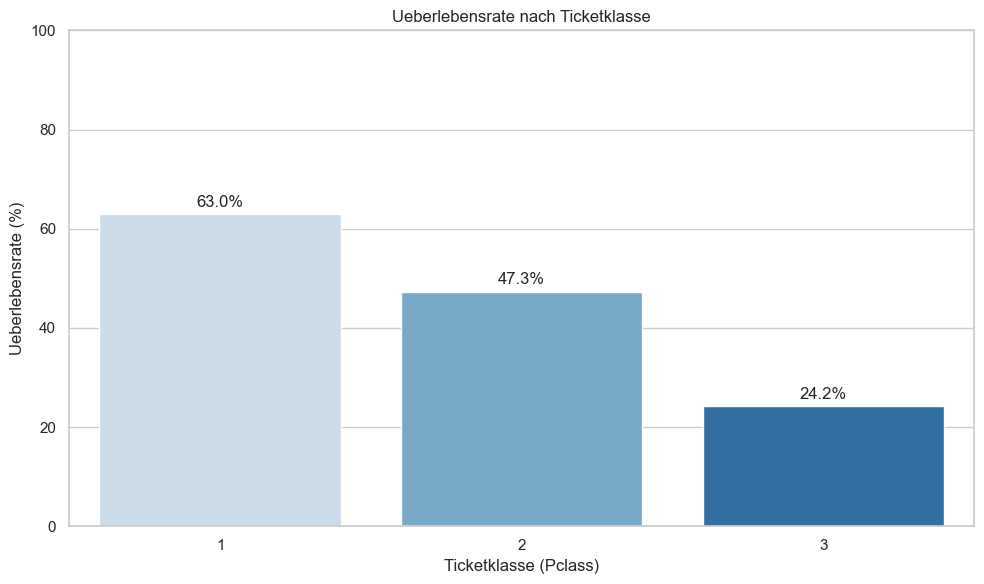

In [14]:
survival_by_class = (df.groupby(pclass_col)[target_col].mean() * 100).sort_index()

plot_df = pd.DataFrame({
    'Pclass': survival_by_class.index.astype(str),
    'Rate': survival_by_class.values
})

ax = sns.barplot(data=plot_df, x='Pclass', y='Rate', hue='Pclass', palette='Blues', legend=False)
ax.set_title('Ueberlebensrate nach Ticketklasse')
ax.set_xlabel('Ticketklasse (Pclass)')
ax.set_ylabel('Ueberlebensrate (%)')
ax.set_ylim(0, 100)

for i, v in enumerate(plot_df['Rate']):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## Visualisierung 3: Altersverteilung nach Ueberlebensstatus (H3)

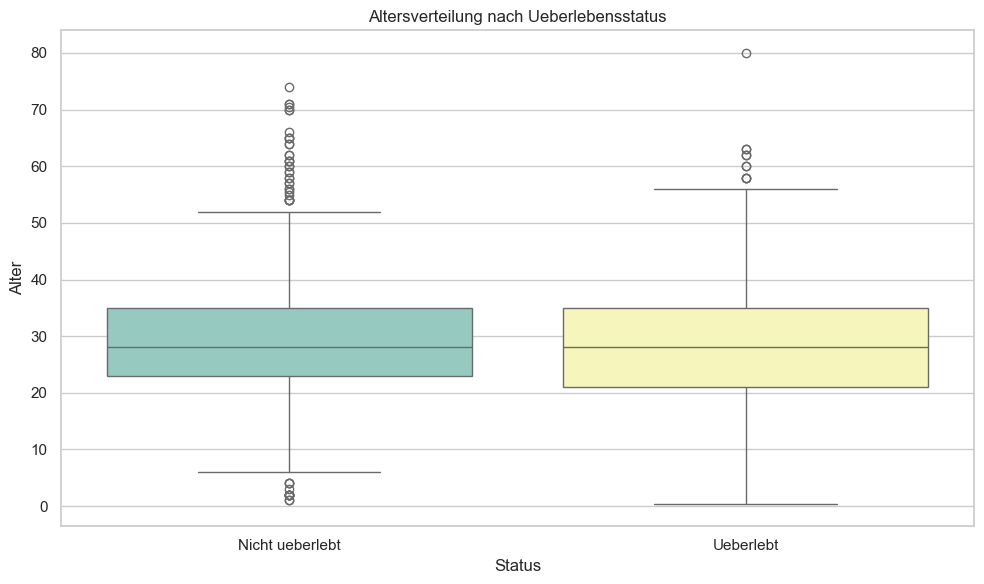

In [15]:
label_map = {0: 'Nicht ueberlebt', 1: 'Ueberlebt'}
df_plot = df.copy()
df_plot['survival_label'] = df_plot[target_col].map(label_map)

ax = sns.boxplot(data=df_plot, x='survival_label', y=age_col, hue='survival_label', palette='Set3', legend=False)
ax.set_title('Altersverteilung nach Ueberlebensstatus')
ax.set_xlabel('Status')
ax.set_ylabel('Alter')

plt.tight_layout()
plt.show()

## Visualisierung 4: Fahrpreis nach Klasse

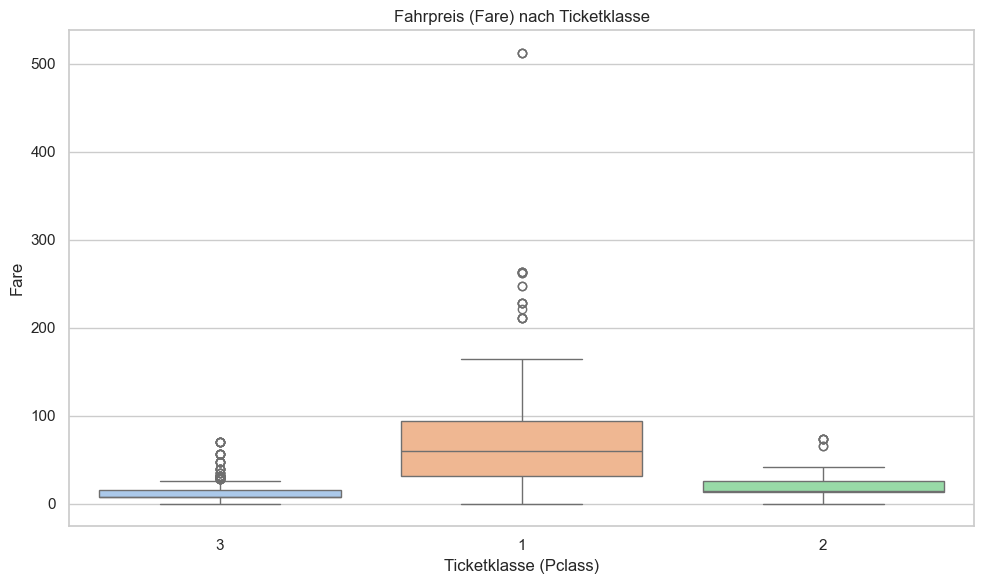

In [16]:
df_fare = df.copy()
df_fare['Pclass_str'] = df_fare[pclass_col].astype(str)

ax = sns.boxplot(data=df_fare, x='Pclass_str', y=fare_col, hue='Pclass_str', palette='pastel', legend=False)
ax.set_title('Fahrpreis (Fare) nach Ticketklasse')
ax.set_xlabel('Ticketklasse (Pclass)')
ax.set_ylabel('Fare')

plt.tight_layout()
plt.show()

## Kurzfazit

- H1 und H2 sind visuell klar erkennbar.
- H3 zeigt Unterschiede, ist aber statistisch nicht robust bestätigt.
